In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

# update when needed
CHECKPOINT_DIR = Path("../checkpoints_ResNets2026")
print(CHECKPOINT_DIR)
DEVICE = "cpu"

../checkpoints_ResNets2026


In [2]:
def load_checkpoints(directory: Path) -> dict:
    runs = {}
    for path in sorted(directory.glob("*.pt")):
        ckpt = torch.load(path, map_location=DEVICE)
        run_name = path.stem
        runs[run_name] = ckpt["history"]
        print(f"Loaded: {run_name:40s} | epochs: {len(ckpt['history']['train_loss'])}")
    return runs

runs = load_checkpoints(CHECKPOINT_DIR)

Loaded: custom_resnet18_ce_adam                  | epochs: 40
Loaded: custom_resnet18_ce_rmsprop               | epochs: 40
Loaded: custom_resnet18_mm_adam                  | epochs: 40
Loaded: custom_resnet34_ce_adam                  | epochs: 40
Loaded: pretrained_resnet18_ce_adam              | epochs: 40
Loaded: pretrained_resnet18_ce_rmsprop           | epochs: 40
Loaded: pretrained_resnet18_freezed_ce_adam      | epochs: 40
Loaded: pretrained_resnet18_mm_adam              | epochs: 24
Loaded: pretrained_resnet50_ce_adam              | epochs: 40
Loaded: pretrained_resnet50_freezed_ce_adam      | epochs: 40


In [3]:
def summary_table(runs: dict):
    header = f"{'Run':<40} {'Epochs':>6} {'Best Val Loss':>14} {'Best Val Acc':>13} {'Final Val Acc':>14}"
    print(header)
    print("-" * len(header))
    for name, h in runs.items():
        epochs      = len(h["train_loss"])
        best_loss   = min(h["val_loss"])
        best_acc    = max(h["val_acc"])
        final_acc   = h["val_acc"][-1]
        print(f"{name:<40} {epochs:>6} {best_loss:>14.4f} {best_acc:>13.4f} {final_acc:>14.4f}")

summary_table(runs)

Run                                      Epochs  Best Val Loss  Best Val Acc  Final Val Acc
-------------------------------------------------------------------------------------------
custom_resnet18_ce_adam                      40         1.2151        0.8865         0.8865
custom_resnet18_ce_rmsprop                   40         1.5035        0.8058         0.8029
custom_resnet18_mm_adam                      40         0.0262        0.8221         0.8221
custom_resnet34_ce_adam                      40         1.2171        0.8827         0.8798
pretrained_resnet18_ce_adam                  40         0.9943        0.9413         0.9394
pretrained_resnet18_ce_rmsprop               40         1.0376        0.9250         0.9221
pretrained_resnet18_freezed_ce_adam          40         1.9048        0.7529         0.7490
pretrained_resnet18_mm_adam                  24         0.0091        0.9212         0.9192
pretrained_resnet50_ce_adam                  40         0.9239        0.9606    

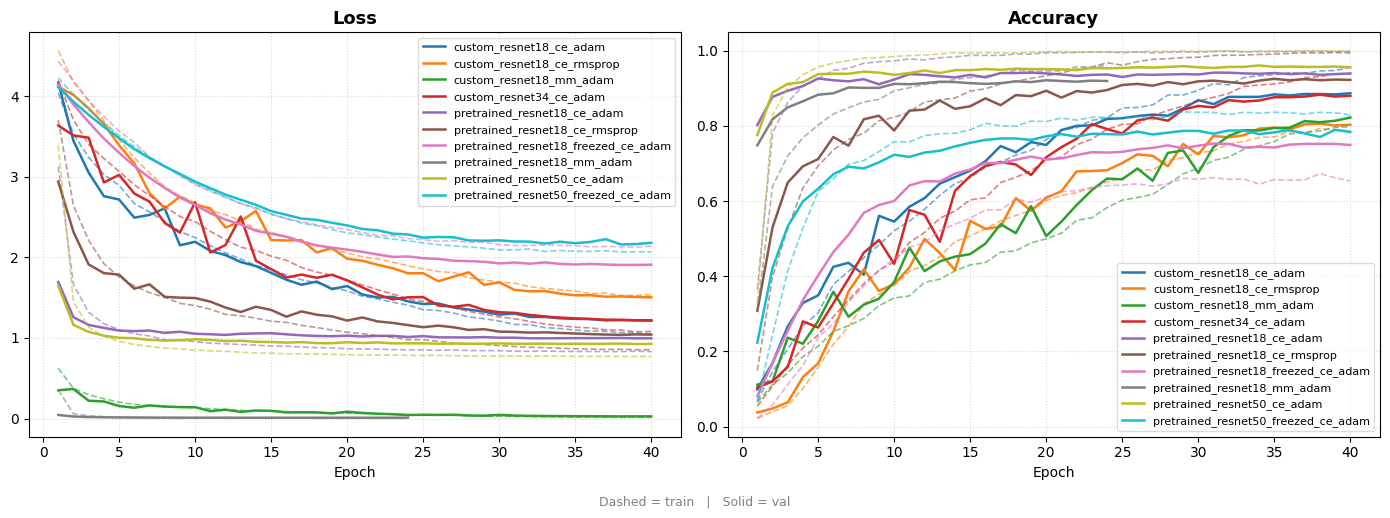

In [4]:
def plot_curves(runs: dict, metric_pairs=(("train_loss", "val_loss"), ("train_acc", "val_acc"))):
    n_metrics = len(metric_pairs)
    fig, axes = plt.subplots(1, n_metrics, figsize=(7 * n_metrics, 5))
    if n_metrics == 1:
        axes = [axes]

    cmap = plt.get_cmap("tab10")
    colors = {name: cmap(i % 10) for i, name in enumerate(runs)}

    titles = {"train_loss": "Loss", "val_loss": "Loss", "train_acc": "Accuracy", "val_acc": "Accuracy"}

    for ax, (train_key, val_key) in zip(axes, metric_pairs):
        for name, h in runs.items():
            epochs = range(1, len(h[train_key]) + 1)
            ax.plot(epochs, h[train_key], color=colors[name], linestyle="--", alpha=0.6, linewidth=1.2)
            ax.plot(epochs, h[val_key],   color=colors[name], linestyle="-",  linewidth=1.8, label=name)

        ax.set_title(titles[train_key], fontsize=13, fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
        ax.grid(True, linestyle=":", alpha=0.5)
        ax.legend(fontsize=8, framealpha=0.7)

    fig.text(0.5, -0.02, "Dashed = train   |   Solid = val", ha="center", fontsize=9, color="gray")
    plt.tight_layout()
    plt.show()

plot_curves(runs)

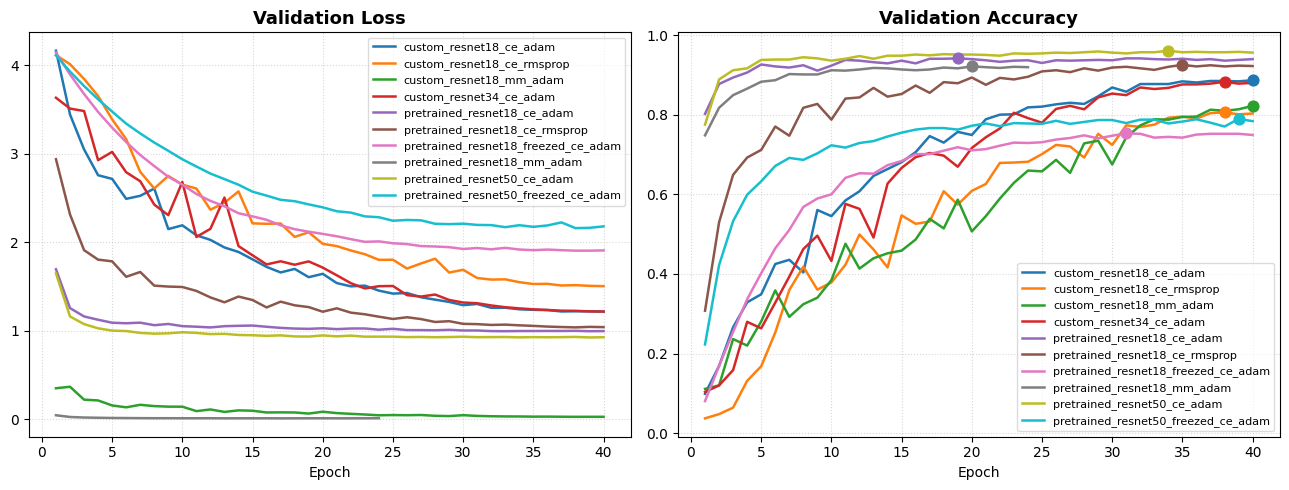

In [5]:
def plot_val_comparison(runs: dict):
    fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(13, 5))
    cmap = plt.get_cmap("tab10")

    for i, (name, h) in enumerate(runs.items()):
        color  = cmap(i % 10)
        epochs = range(1, len(h["val_loss"]) + 1)
        ax_loss.plot(epochs, h["val_loss"], color=color, linewidth=1.8, label=name)
        ax_acc.plot( epochs, h["val_acc"],  color=color, linewidth=1.8, label=name)

        best_epoch = int(np.argmax(h["val_acc"])) + 1
        best_val   = max(h["val_acc"])
        ax_acc.scatter(best_epoch, best_val, color=color, s=60, zorder=5)

    for ax, title in zip([ax_loss, ax_acc], ["Validation Loss", "Validation Accuracy"]):
        ax.set_title(title, fontsize=13, fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
        ax.grid(True, linestyle=":", alpha=0.5)
        ax.legend(fontsize=8, framealpha=0.7)

    plt.tight_layout()
    plt.show()

plot_val_comparison(runs)

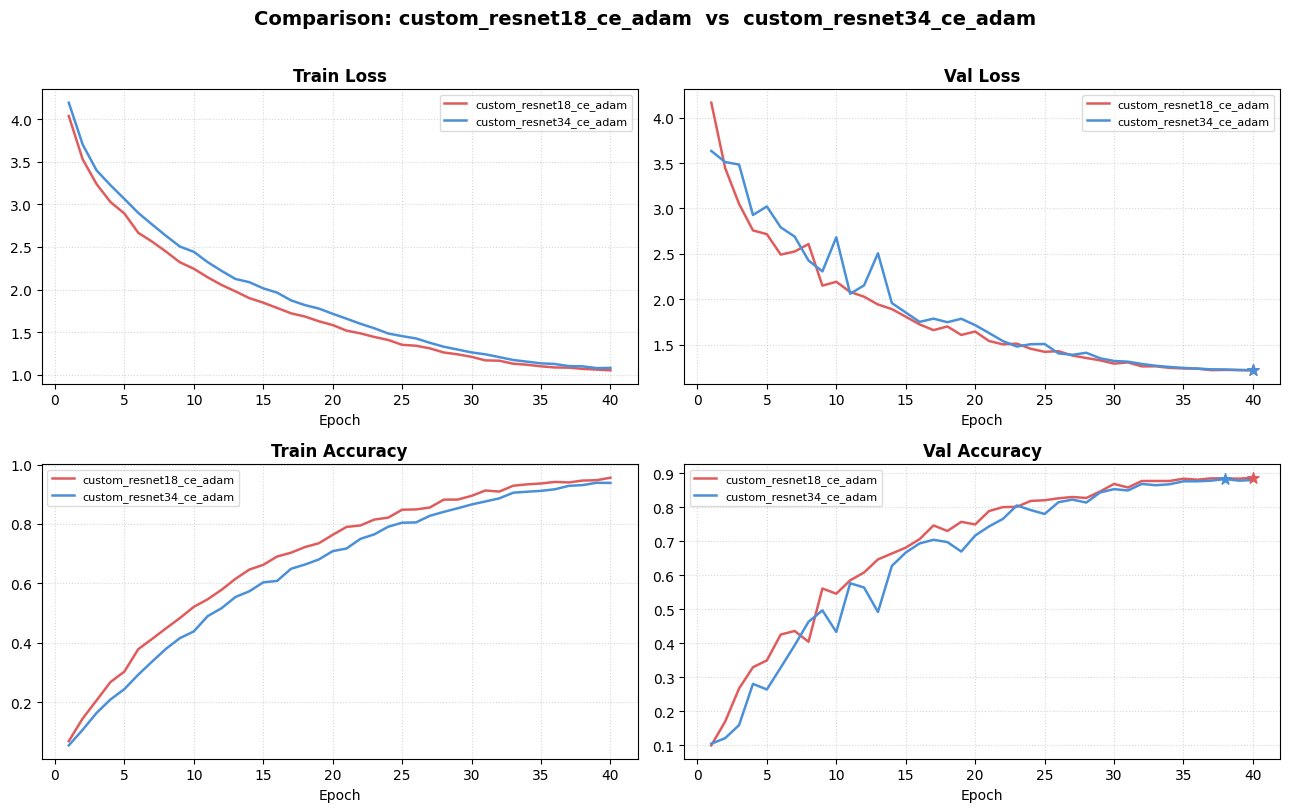


Metric                           custom_resnet18_ce_adam        custom_resnet34_ce_adam
---------------------------------------------------------------------------------------
Epochs                                                40                             40
Best val loss                                     1.2151                         1.2171
Best val acc                                      0.8865                         0.8827
Final val loss                                    1.2151                         1.2171
Final val acc                                     0.8865                         0.8798
Final train acc                                   0.9555                         0.9380
Overfit gap (final)                               0.0690                         0.0582


In [6]:
def compare_two_checkpoints(name_a: str, name_b: str, runs: dict):
    assert name_a in runs, f"'{name_a}' not found in loaded runs."
    assert name_b in runs, f"'{name_b}' not found in loaded runs."

    ha, hb = runs[name_a], runs[name_b]
    color_a, color_b = "#e05c5c", "#4a90d9"

    metrics = [
        ("train_loss",  "Train Loss",      False),
        ("val_loss",    "Val Loss",         True),
        ("train_acc",   "Train Accuracy",   False),
        ("val_acc",     "Val Accuracy",     True),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    axes = axes.flatten()

    for ax, (key, title, mark_best) in zip(axes, metrics):
        for name, h, color in [(name_a, ha, color_a), (name_b, hb, color_b)]:
            values = h[key]
            epochs = range(1, len(values) + 1)
            ax.plot(epochs, values, color=color, linewidth=1.8, label=name)

            if mark_best:
                if "loss" in key:
                    best_idx = int(np.argmin(values))
                else:
                    best_idx = int(np.argmax(values))
                ax.scatter(best_idx + 1, values[best_idx], color=color, s=70, zorder=5, marker="*")

        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
        ax.grid(True, linestyle=":", alpha=0.5)
        ax.legend(fontsize=8, framealpha=0.7)

    fig.suptitle(f"Comparison: {name_a}  vs  {name_b}", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

    # --- text summary ---
    print(f"\n{'Metric':<25} {name_a:>30} {name_b:>30}")
    print("-" * 87)
    summary_metrics = [
        ("Epochs",         len(ha['train_loss']),      len(hb['train_loss'])),
        ("Best val loss",  min(ha['val_loss']),         min(hb['val_loss'])),
        ("Best val acc",   max(ha['val_acc']),          max(hb['val_acc'])),
        ("Final val loss", ha['val_loss'][-1],          hb['val_loss'][-1]),
        ("Final val acc",  ha['val_acc'][-1],           hb['val_acc'][-1]),
        ("Final train acc",ha['train_acc'][-1],         hb['train_acc'][-1]),
        ("Overfit gap (final)",
         ha['train_acc'][-1] - ha['val_acc'][-1],
         hb['train_acc'][-1] - hb['val_acc'][-1]),
    ]
    for label, va, vb in summary_metrics:
        va_str = f"{va}" if isinstance(va, int) else f"{va:.4f}"
        vb_str = f"{vb}" if isinstance(vb, int) else f"{vb:.4f}"
        print(f"{label:<25} {va_str:>30} {vb_str:>30}")


compare_two_checkpoints("custom_resnet18_ce_adam", "custom_resnet34_ce_adam", runs)